# 🎯 Customer Churn — Ensemble v7
**Kaggle Playground Series 2026**

Changes vs v6:
- MLP replaced with CatBoost
- CatBoost handles categoricals differently → less correlated with LGB/XGB
- LGB + XGB + CatBoost + Hill Climbing

### Structure
1. Setup & Load
2. LightGBM — 5-fold CV
3. XGBoost — 5-fold CV
4. CatBoost — 5-fold CV
5. Hill Climbing
6. OOF Analysis
7. Submission

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv").drop(columns=['risk_score'], errors='ignore')
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv").drop(columns=['risk_score'], errors='ignore')
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

FEATURE_COLS = X_train.columns.tolist()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 40)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 40)


---
## 2. LightGBM — 5-Fold CV

Carried over from v6.

In [2]:
params_lgb = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.04,
    'num_leaves'       : 29,
    'max_depth'        : 6,
    'min_child_samples': 100,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 150,
    'is_unbalance'     : True,
    'verbose'          : -1,
    'random_state'     : SEED,
}

oof_lgb    = np.zeros(len(X_train))
tst_lgb    = np.zeros(len(X_test))
scores_lgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params_lgb, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(200),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    tst_lgb         += model.predict(X_test) / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    scores_lgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_lgb = roc_auc_score(y_train, oof_lgb)
print(f"\n  LGB OOF AUC : {auc_lgb:.5f}")
print(f"  Mean        : {np.mean(scores_lgb):.5f} +/- {np.std(scores_lgb):.5f}")


[200]	valid_0's auc: 0.914437
[400]	valid_0's auc: 0.915409
[600]	valid_0's auc: 0.915752
[800]	valid_0's auc: 0.915891
[1000]	valid_0's auc: 0.915946
  Fold 1 — AUC: 0.91598 | best iter: 1045
[200]	valid_0's auc: 0.91554
[400]	valid_0's auc: 0.91649
[600]	valid_0's auc: 0.916756
[800]	valid_0's auc: 0.916983
[1000]	valid_0's auc: 0.91709
[1200]	valid_0's auc: 0.917135
[1400]	valid_0's auc: 0.917154
[1600]	valid_0's auc: 0.917173
[1800]	valid_0's auc: 0.917178
  Fold 2 — AUC: 0.91719 | best iter: 1695
[200]	valid_0's auc: 0.914866
[400]	valid_0's auc: 0.915879
[600]	valid_0's auc: 0.91622
[800]	valid_0's auc: 0.916416
[1000]	valid_0's auc: 0.916505
[1200]	valid_0's auc: 0.916554
[1400]	valid_0's auc: 0.916584
[1600]	valid_0's auc: 0.916607
[1800]	valid_0's auc: 0.916596
  Fold 3 — AUC: 0.91661 | best iter: 1701
[200]	valid_0's auc: 0.915979
[400]	valid_0's auc: 0.916912
[600]	valid_0's auc: 0.917259
[800]	valid_0's auc: 0.91746
[1000]	valid_0's auc: 0.917571
[1200]	valid_0's auc: 0.917

---
## 3. XGBoost — 5-Fold CV

Carried over from v6.

In [3]:
params_xgb = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'learning_rate'    : 0.04,
    'max_depth'        : 5,
    'min_child_weight' : 50,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 150,
    'scale_pos_weight' : (y_train==0).sum() / (y_train==1).sum(),
    'tree_method'      : 'hist',
    'random_state'     : SEED,
    'verbosity'        : 0,
}

oof_xgb    = np.zeros(len(X_train))
tst_xgb    = np.zeros(len(X_test))
scores_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params_xgb, dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=150,
        verbose_eval=200,
    )

    oof_xgb[val_idx] = model.predict(dval)
    tst_xgb         += model.predict(xgb.DMatrix(X_test)) / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    scores_xgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_xgb = roc_auc_score(y_train, oof_xgb)
print(f"\n  XGB OOF AUC : {auc_xgb:.5f}")
print(f"  Mean        : {np.mean(scores_xgb):.5f} +/- {np.std(scores_xgb):.5f}")
print(f"  vs LGB      : {auc_xgb - auc_lgb:+.5f}")


[0]	val-auc:0.89680
[200]	val-auc:0.91417
[400]	val-auc:0.91521
[600]	val-auc:0.91565
[800]	val-auc:0.91586
[1000]	val-auc:0.91598
[1200]	val-auc:0.91606
[1400]	val-auc:0.91609
[1600]	val-auc:0.91612
[1800]	val-auc:0.91613
[1860]	val-auc:0.91613
  Fold 1 — AUC: 0.91613 | best iter: 1710
[0]	val-auc:0.89697
[200]	val-auc:0.91521
[400]	val-auc:0.91623
[600]	val-auc:0.91666
[800]	val-auc:0.91693
[1000]	val-auc:0.91707
[1200]	val-auc:0.91716
[1400]	val-auc:0.91722
[1600]	val-auc:0.91725
[1800]	val-auc:0.91727
[1999]	val-auc:0.91728
  Fold 2 — AUC: 0.91728 | best iter: 1997
[0]	val-auc:0.89675
[200]	val-auc:0.91468
[400]	val-auc:0.91580
[600]	val-auc:0.91620
[800]	val-auc:0.91642
[1000]	val-auc:0.91657
[1200]	val-auc:0.91664
[1400]	val-auc:0.91669
[1600]	val-auc:0.91671
[1800]	val-auc:0.91673
[1955]	val-auc:0.91671
  Fold 3 — AUC: 0.91671 | best iter: 1806
[0]	val-auc:0.89740
[200]	val-auc:0.91575
[400]	val-auc:0.91676
[600]	val-auc:0.91720
[800]	val-auc:0.91744
[1000]	val-auc:0.91754
[1200

---
## 4. CatBoost — 5-Fold CV

CatBoost differs from LGB/XGB in three key ways:
- **Ordered boosting** — avoids target leakage during training
- **Symmetric trees** — same split at every level of the tree
- **Built-in categorical handling** — though here features are already encoded

These differences tend to produce less correlated predictions vs LGB/XGB.
`auto_class_weights='Balanced'` handles the 77/23 imbalance.

In [4]:
oof_cat    = np.zeros(len(X_train))
tst_cat    = np.zeros(len(X_test))
scores_cat = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = CatBoostClassifier(
        iterations        = 2000,
        learning_rate     = 0.04,
        depth             = 6,
        l2_leaf_reg       = 150,
        min_data_in_leaf  = 50,
        auto_class_weights= 'Balanced',
        eval_metric       = 'AUC',
        early_stopping_rounds = 150,
        random_seed       = SEED,
        verbose           = 200,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    oof_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    tst_cat         += model.predict_proba(X_test)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_cat[val_idx])
    scores_cat.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration_}")

auc_cat = roc_auc_score(y_train, oof_cat)
print(f"\n  CAT OOF AUC : {auc_cat:.5f}")
print(f"  Mean        : {np.mean(scores_cat):.5f} +/- {np.std(scores_cat):.5f}")
print(f"  vs LGB      : {auc_cat - auc_lgb:+.5f}")
print(f"  vs XGB      : {auc_cat - auc_xgb:+.5f}")

# ── Diversity check ────────────────────────────────────────────────────────
print("\nOOF correlation (lower = more diverse = better for ensemble):")
oof_df = pd.DataFrame({'LGB': oof_lgb, 'XGB': oof_xgb, 'CAT': oof_cat})
print(oof_df.corr().round(4).to_string())


0:	test: 0.8953110	best: 0.8953110 (0)	total: 216ms	remaining: 7m 12s
200:	test: 0.9136212	best: 0.9136212 (200)	total: 55.5s	remaining: 8m 16s
400:	test: 0.9145752	best: 0.9145752 (400)	total: 1m 33s	remaining: 6m 13s
600:	test: 0.9151639	best: 0.9151639 (600)	total: 2m 7s	remaining: 4m 57s
800:	test: 0.9155094	best: 0.9155094 (800)	total: 2m 41s	remaining: 4m 2s
1000:	test: 0.9157030	best: 0.9157043 (999)	total: 3m 13s	remaining: 3m 13s
1200:	test: 0.9158464	best: 0.9158464 (1198)	total: 3m 43s	remaining: 2m 28s
1400:	test: 0.9159088	best: 0.9159117 (1394)	total: 4m 13s	remaining: 1m 48s
1600:	test: 0.9159641	best: 0.9159649 (1598)	total: 4m 29s	remaining: 1m 7s
1800:	test: 0.9159923	best: 0.9159938 (1795)	total: 4m 47s	remaining: 31.8s
1999:	test: 0.9160350	best: 0.9160360 (1992)	total: 5m 8s	remaining: 0us

bestTest = 0.9160359502
bestIteration = 1992

Shrink model to first 1993 iterations.
  Fold 1 — AUC: 0.91604 | best iter: 1992
0:	test: 0.8960297	best: 0.8960297 (0)	total: 106m

---
## 5. Hill Climbing

Same algorithm as v6 — now with LGB + XGB + CatBoost.
Hoping CatBoost correlation with LGB/XGB is lower than 0.9987.

In [5]:
def hill_climbing(oofs, y, n_iter=3000, step=0.01):
    n_models = len(oofs)
    weights  = np.array([1.0 / n_models] * n_models)

    best_auc = roc_auc_score(y, sum(w * o for w, o in zip(weights, oofs)))
    print(f"Starting AUC (equal weights): {best_auc:.5f}")
    print(f"  Initial weights: {[round(w,3) for w in weights]}\n")

    improved  = True
    iteration = 0

    while improved and iteration < n_iter:
        improved = False
        iteration += 1
        for i in range(n_models):
            new_w = weights.copy()
            new_w[i] += step
            new_w /= new_w.sum()
            auc = roc_auc_score(y, sum(w * o for w, o in zip(new_w, oofs)))
            if auc > best_auc:
                best_auc = auc
                weights  = new_w
                improved = True

    print(f"Converged after {iteration} iterations")
    print(f"Best OOF AUC : {best_auc:.5f}")
    print(f"Best weights :")
    for name, w in zip(['LGB', 'XGB', 'CAT'], weights):
        print(f"  {name} : {w:.4f} ({w*100:.1f}%)")
    return weights, best_auc


oofs = [oof_lgb, oof_xgb, oof_cat]
tsts = [tst_lgb, tst_xgb, tst_cat]

best_weights, auc_blend = hill_climbing(oofs, y_train)

print(f"\n{'='*45}")
print(f"  LGB alone   : {auc_lgb:.5f}")
print(f"  XGB alone   : {auc_xgb:.5f}")
print(f"  CAT alone   : {auc_cat:.5f}")
print(f"  Equal blend : {roc_auc_score(y_train, sum(o/3 for o in oofs)):.5f}")
print(f"  Hill climb  : {auc_blend:.5f}  ← best")
print(f"  vs LGB alone: {auc_blend - auc_lgb:+.5f}")
print(f"  vs v6 blend : {auc_blend - 0.91662:+.5f}")
print(f"{'='*45}")

tst_blend = sum(w * t for w, t in zip(best_weights, tsts))


Starting AUC (equal weights): 0.91669
  Initial weights: [0.333, 0.333, 0.333]

Converged after 25 iterations
Best OOF AUC : 0.91669
Best weights :
  LGB : 0.2307 (23.1%)
  XGB : 0.4312 (43.1%)
  CAT : 0.3381 (33.8%)

  LGB alone   : 0.91647
  XGB alone   : 0.91656
  CAT alone   : 0.91643
  Equal blend : 0.91669
  Hill climb  : 0.91669  ← best
  vs LGB alone: +0.00023
  vs v6 blend : +0.00007


---
## 6. OOF Analysis

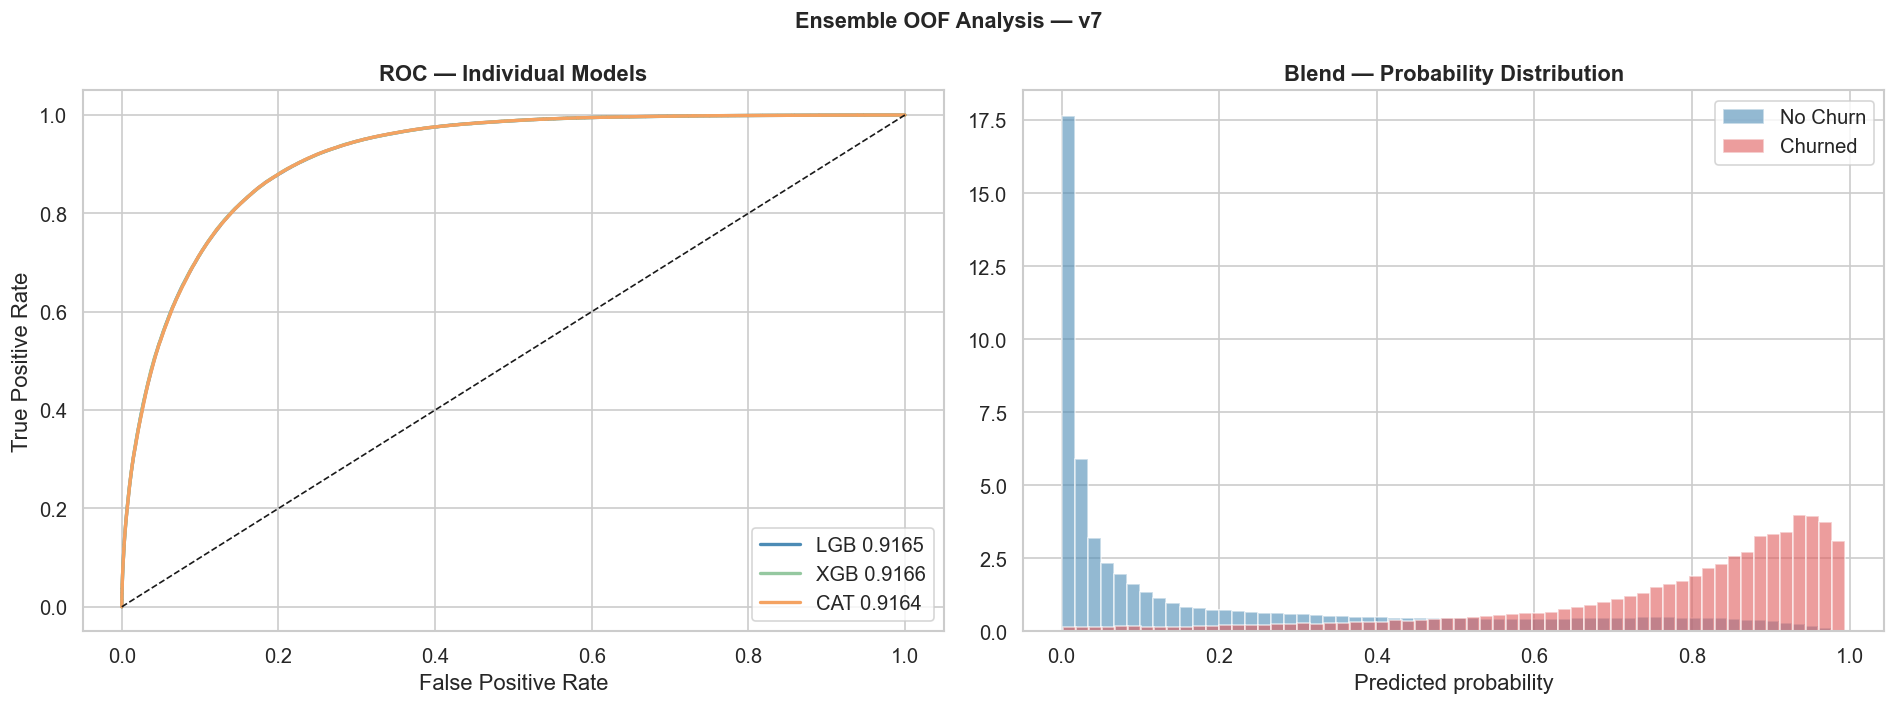

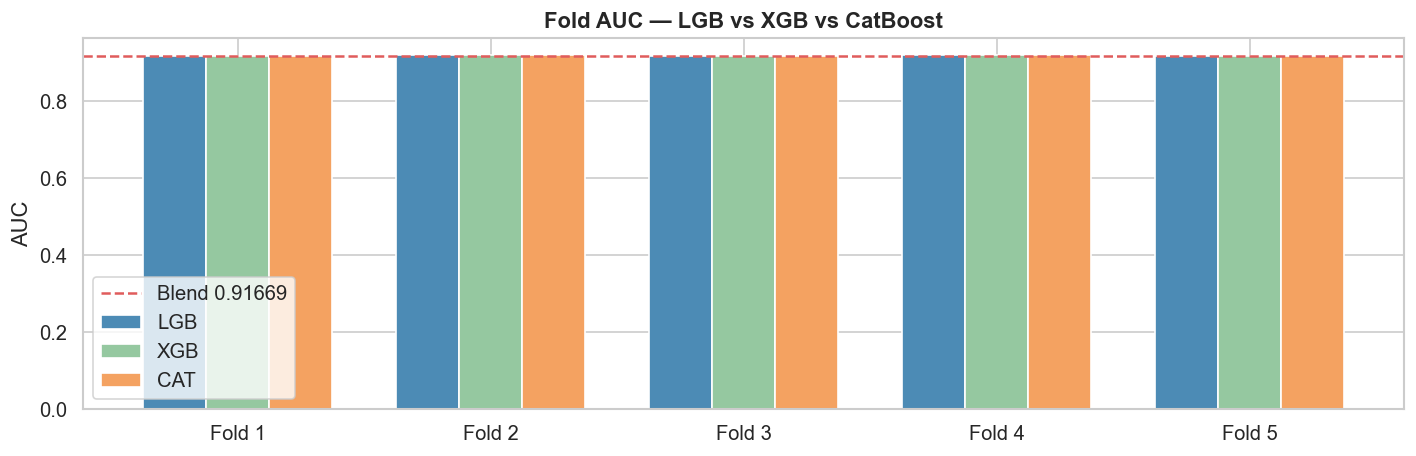

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, oof, auc, color in [
    ('LGB', oof_lgb, auc_lgb, '#4C8BB5'),
    ('XGB', oof_xgb, auc_xgb, '#95C8A0'),
    ('CAT', oof_cat, auc_cat, '#F4A261'),
]:
    fpr, tpr, _ = roc_curve(y_train, oof)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_title('ROC — Individual Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

oof_final = sum(w * o for w, o in zip(best_weights, oofs))
axes[1].hist(oof_final[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_final[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Blend — Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

plt.suptitle('Ensemble OOF Analysis — v7', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
x  = np.arange(N_FOLDS)
bw = 0.25
ax.bar(x - bw,  scores_lgb, width=bw, label='LGB', color='#4C8BB5', edgecolor='white')
ax.bar(x,       scores_xgb, width=bw, label='XGB', color='#95C8A0', edgecolor='white')
ax.bar(x + bw,  scores_cat, width=bw, label='CAT', color='#F4A261', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, N_FOLDS+1)])
ax.axhline(auc_blend, color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'Blend {auc_blend:.5f}')
ax.set_title('Fold AUC — LGB vs XGB vs CatBoost', fontweight='bold')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.show()


---
## 7. Submission

Sanity checks: ✅
Rows      : 254,655
Churn mean: 0.3413  (train: 0.2252)

Final summary:
  LGB alone  : OOF 0.91647
  XGB alone  : OOF 0.91656
  CAT alone  : OOF 0.91643
  Blend      : OOF 0.91669
  Weights    : LGB=0.23 XGB=0.43 CAT=0.34

  v6 LB      : 0.91409
  Target     : 0.91726 (best public notebook)


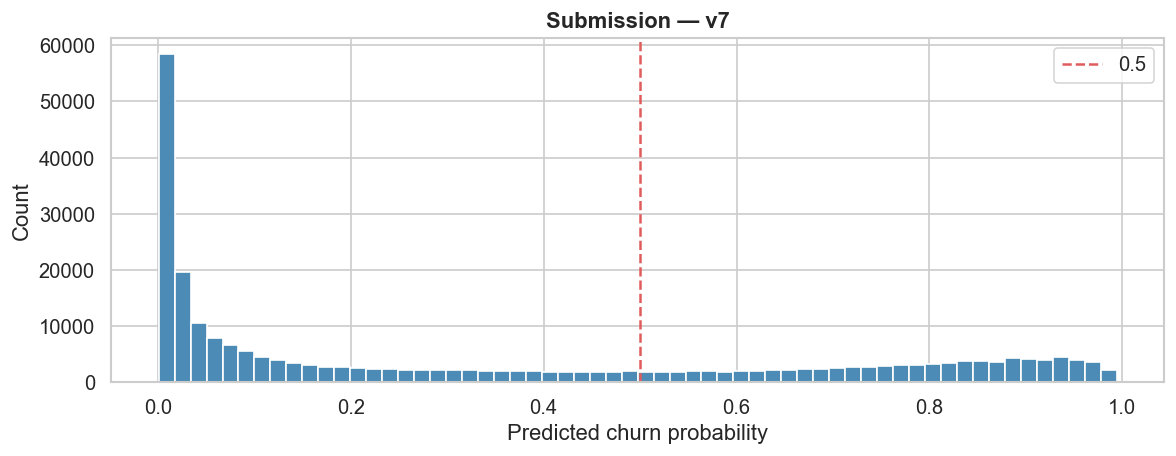


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submission_v7.csv


In [7]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_blend
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows      : {len(submission):,}")
print(f"Churn mean: {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nFinal summary:")
print(f"  LGB alone  : OOF {auc_lgb:.5f}")
print(f"  XGB alone  : OOF {auc_xgb:.5f}")
print(f"  CAT alone  : OOF {auc_cat:.5f}")
print(f"  Blend      : OOF {auc_blend:.5f}")
print(f"  Weights    : LGB={best_weights[0]:.2f} XGB={best_weights[1]:.2f} CAT={best_weights[2]:.2f}")
print(f"\n  v6 LB      : 0.91409")
print(f"  Target     : 0.91726 (best public notebook)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(0.5, color='#E05C5C', linestyle='--', linewidth=1.5, label='0.5')
ax.set_title('Submission — v7', fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submission_v7.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submission_v7.csv")
